# Bài giảng 2: Data Preparation trong Tài chính
---
Data Preparation (Chuẩn bị dữ liệu) là công việc nhàm chán nhưng lại là xương sống không thể thiếu của bất kỳ dự án Machine Learning thành công nào, đặc biệt là trong Quantitative Finance (Tài chính định lượng). Trong học phần kéo dài 3 tuần này, chúng ta sẽ khám phá ba trụ cột quan trọng để chuẩn bị dữ liệu:
1. **Data Cleaning** (Xử lý Missing Values và Outliers)
2. **Data Transformation** (Scaling, Encoding, và xử lý dữ liệu mất cân bằng)
3. **Feature Selection** (Lọc tín hiệu từ nhiễu)


## Phần 1: Data Cleaning (Tuần 3)
---
Dữ liệu tài chính nổi tiếng là lộn xộn. Giá tài sản có thể bị thiếu vào các ngày nghỉ lễ, dữ liệu thay thế (alternative data) có thể có những khoảng trống cấu trúc, và các sự kiện "flash crash" có thể tạo ra các outliers khổng lồ.


### 1.1 Hiểu về cơ chế của Missing Data
Trước khi có thể xử lý dữ liệu bị thiếu, chúng ta phải hiểu *tại sao* nó bị thiếu.
* **MCAR (Missing Completely At Random):** Xác suất bị thiếu là như nhau cho tất cả các quan sát. (ví dụ: một cảm biến ngẫu nhiên bị hỏng).
* **MAR (Missing At Random):** Xác suất bị thiếu phụ thuộc vào dữ liệu đã quan sát. (ví dụ: người lớn tuổi có thể ít khả năng điền vào một cuộc khảo sát công nghệ hơn, nhưng một khi chúng ta kiểm soát độ tuổi, sự thiếu hụt là ngẫu nhiên).
* **MNAR (Missing Not At Random):** Xác suất bị thiếu phụ thuộc vào chính giá trị không được quan sát đó. (ví dụ: những người có thu nhập cực cao có thể từ chối tiết lộ thu nhập của họ).

> **Important:** Trong tài chính, MNAR rất phổ biến! Ví dụ, một tài sản thanh khoản kém (illiquid) có thể không có giá vào một ngày cụ thể *bởi vì* nó thanh khoản kém.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Tạo dữ liệu giả lập với Missing Values
np.random.seed(42)
dates = pd.date_range(start='2023-01-01', periods=100, freq='D')
df = pd.DataFrame({
    'Date': dates,
    'Stock_A_Price': 100 + np.random.randn(100).cumsum(),
    'Stock_B_Price': 50 + np.random.randn(100).cumsum(),
    'Volume': np.random.randint(1000, 10000, size=100),
    'Sector': np.random.choice(['Tech', 'Finance', 'Energy'], size=100)
})

# Đưa vào một số Missing Values (MCAR)
df.loc[10:15, 'Stock_A_Price'] = np.nan
df.loc[45:50, 'Stock_B_Price'] = np.nan
df.loc[80:85, 'Volume'] = np.nan

# Kiểm tra Missing Values
print("Tổng hợp Missing Values:")
print(df.isnull().sum())


Tổng hợp Missing Values:
Date             0
Stock_A_Price    6
Stock_B_Price    6
Volume           6
Sector           0
dtype: int64


### 1.2 Xử lý Missing Data

#### Chiến lược A: Xóa bỏ (Deletion)
Nếu dữ liệu là MCAR và tỷ lệ Missing Data rất nhỏ (<5%), chúng ta có thể chỉ cần xóa các hàng đó.
* **Listwise Deletion:** Xóa bất kỳ hàng nào chứa ít nhất một Missing Value.


In [2]:
# Listwise deletion
df_dropped = df.dropna()
print(f"Kích thước ban đầu: {df.shape}")
print(f"Kích thước sau khi xóa: {df_dropped.shape}")


Kích thước ban đầu: (100, 5)
Kích thước sau khi xóa: (82, 5)


#### Chiến lược B: Imputation Cơ bản
Chúng ta thay thế Missing Values bằng một ước tính thống kê (Mean, Median, Mode).
* **Mean:** Tốt cho dữ liệu liên tục phân phối chuẩn. Nhạy cảm với Outliers.
* **Median:** Robust (mạnh mẽ) với Outliers. Lý tưởng cho dữ liệu bị lệch (như thu nhập hoặc lợi nhuận).
* **Mode:** Được sử dụng cho Categorical Data.


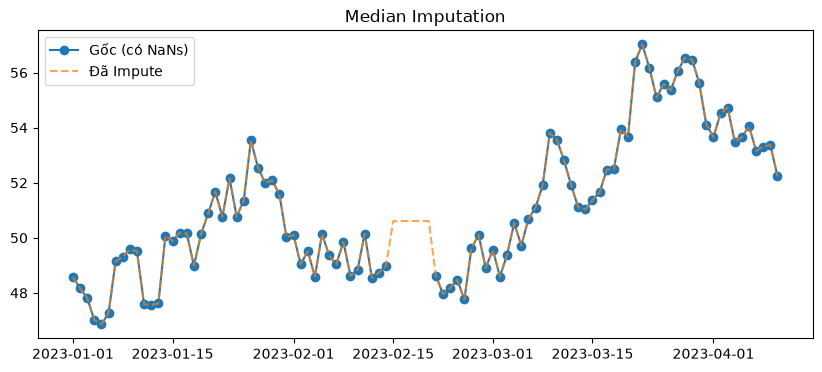

In [3]:
from sklearn.impute import SimpleImputer

# Imputing bằng Median
imputer = SimpleImputer(strategy='median')
df['Stock_B_Price_Imputed'] = imputer.fit_transform(df[['Stock_B_Price']])

# Trực quan hóa Imputation
plt.figure(figsize=(10,4))
plt.plot(df['Date'], df['Stock_B_Price'], label='Gốc (có NaNs)', marker='o')
plt.plot(df['Date'], df['Stock_B_Price_Imputed'], label='Đã Impute', linestyle='--', alpha=0.7)
plt.legend()
plt.title("Median Imputation")
plt.show()


#### Chiến lược C: Imputation đặc thù cho Time-Series
Dữ liệu tài chính có tính tuần tự. Việc thay thế giá cổ phiếu bị thiếu bằng giá trị trung bình toàn cục là một ý tưởng tồi! Chúng ta nên sử dụng các phương pháp theo ngữ cảnh chuỗi thời gian.
* **Forward Fill (`ffill`):** Đẩy giá trị quan sát hợp lệ cuối cùng về phía trước. Rất phổ biến đối với dữ liệu giá để tránh look-ahead bias (thiên kiến nhìn trước tương lai).
* **Linear Interpolation:** Vẽ một đường thẳng giữa các điểm đã biết.


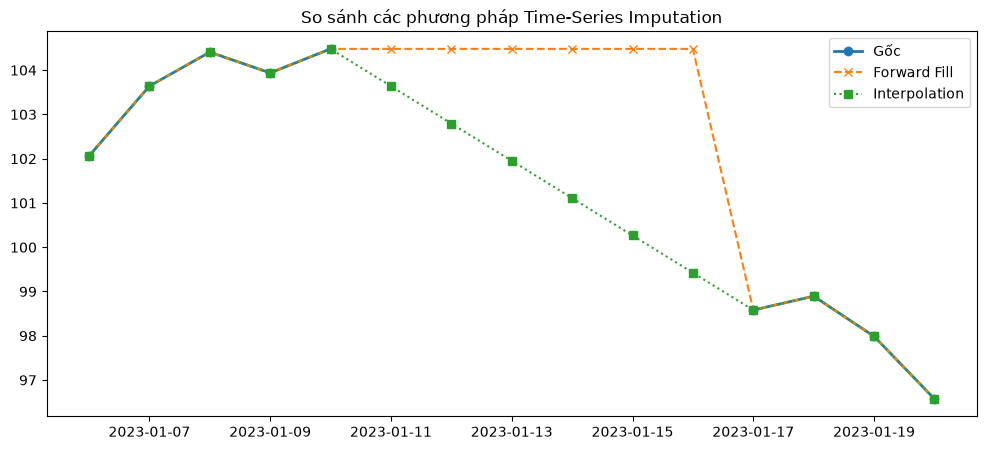

In [4]:
# Forward fill cho Stock A
df['Stock_A_ffill'] = df['Stock_A_Price'].fillna(method='ffill')

# Interpolation cho Stock A
df['Stock_A_interp'] = df['Stock_A_Price'].interpolate(method='linear')

plt.figure(figsize=(12,5))
plt.plot(df['Date'][5:20], df['Stock_A_Price'][5:20], label='Gốc', marker='o', linewidth=2)
plt.plot(df['Date'][5:20], df['Stock_A_ffill'][5:20], label='Forward Fill', marker='x', linestyle='--')
plt.plot(df['Date'][5:20], df['Stock_A_interp'][5:20], label='Interpolation', marker='s', linestyle=':')
plt.legend()
plt.title("So sánh các phương pháp Time-Series Imputation")
plt.show()


### 1.3 Xử lý Outliers
Outliers có thể phá hủy hiệu suất của các mô hình dựa trên khoảng cách (như KNN) hoặc các mô hình tuyến tính (như Linear Regression).

#### Phương pháp Z-Score
Giả sử có phân phối chuẩn, ~99.7% dữ liệu nằm trong vòng 3 độ lệch chuẩn so với giá trị trung bình.
$$ Z = rac{x - \mu}{\sigma} $$
Nếu $|Z| > 3$, điểm đó là một outlier.


In [5]:
# Giả lập một sự cố flash crash (giảm giá chớp nhoáng)
df.loc[30, 'Stock_A_Price'] = 10  # Flash crash

mean_a = df['Stock_A_Price'].mean()
std_a = df['Stock_A_Price'].std()
df['Z_Score_A'] = (df['Stock_A_Price'] - mean_a) / std_a

# Tìm Outliers
outliers_z = df[df['Z_Score_A'].abs() > 3]
print("Các Outliers phát hiện bằng Z-Score:")
print(outliers_z[['Date', 'Stock_A_Price', 'Z_Score_A']])


Các Outliers phát hiện bằng Z-Score:
         Date  Stock_A_Price  Z_Score_A
30 2023-01-31           10.0  -8.609141


#### Phương pháp IQR (Robust với các giá trị cực đoan)
Interquartile Range (IQR) là khoảng cách giữa phân vị thứ 75 ($Q3$) và phân vị thứ 25 ($Q1$).
$$ IQR = Q3 - Q1 $$
Lower Bound: $Q1 - 1.5 	imes IQR$
Upper Bound: $Q3 + 1.5 	imes IQR$


In [6]:
Q1 = df['Stock_A_Price'].quantile(0.25)
Q3 = df['Stock_A_Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['Stock_A_Price'] < lower_bound) | (df['Stock_A_Price'] > upper_bound)]
print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
print("Các Outliers phát hiện bằng IQR:")
print(outliers_iqr[['Date', 'Stock_A_Price']])


Lower Bound: 82.16, Upper Bound: 102.95
Các Outliers phát hiện bằng IQR:
         Date  Stock_A_Price
6  2023-01-07     103.640091
7  2023-01-08     104.407525
8  2023-01-09     103.938051
9  2023-01-10     104.480611
30 2023-01-31      10.000000


#### Xử lý Outliers: Winsorization
Thay vì xóa bỏ các Outliers, chúng ta thường "capping" (giới hạn) chúng ở một bách phân vị nhất định (ví dụ: bách phân vị thứ 1 và 99). Kỹ thuật này gọi là Winsorization và là tiêu chuẩn trong tài chính định lượng.


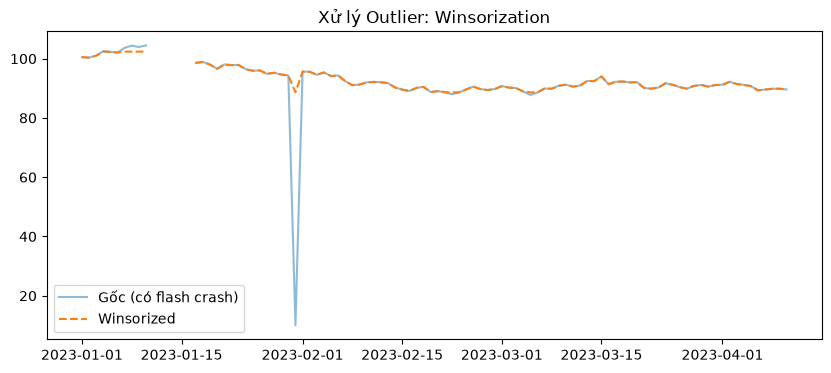

In [7]:
from scipy.stats import mstats

valid_prices = df['Stock_A_Price'].dropna()
lower_cap = valid_prices.quantile(0.05)
upper_cap = valid_prices.quantile(0.95)

df['Stock_A_Winsorized'] = df['Stock_A_Price'].clip(lower=lower_cap, upper=upper_cap)

plt.figure(figsize=(10,4))
plt.plot(df['Date'], df['Stock_A_Price'], label='Gốc (có flash crash)', alpha=0.5)
plt.plot(df['Date'], df['Stock_A_Winsorized'], label='Winsorized', linestyle='--')
plt.legend()
plt.title("Xử lý Outlier: Winsorization")
plt.show()


## Phần 2: Data Transformation (Tuần 4)
---
Một khi dữ liệu đã sạch, nó phải được chuyển đổi thành định dạng số mà các thuật toán Machine Learning có thể dễ dàng tiếp thu.


### 2.1 Feature Scaling
Các thuật toán tính toán khoảng cách (KNN, K-Means) hoặc sử dụng Gradient Descent (Neural Networks, Logistic Regression) cực kỳ nhạy cảm với thang đo của các Features. Nếu 'Thu nhập' chạy từ 0 đến 1.000.000$ và 'Tuổi' chạy từ 0 đến 100, mô hình sẽ tự động ưu tiên Thu nhập đơn giản vì các con số đó lớn hơn.

#### Min-Max Scaling (Normalization)
Chia tỷ lệ dữ liệu về một khoảng cố định, thường là [0, 1].
$$ X_{norm} = rac{X - X_{min}}{X_{max} - X_{min}} $$


In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler_mm = MinMaxScaler()
df['Volume_MinMax'] = scaler_mm.fit_transform(df[['Volume']].fillna(df['Volume'].median()))

print("Thống kê Volume sau Min-Max Scaling:")
print(df['Volume_MinMax'].describe())


Thống kê Volume sau Min-Max Scaling:
count    100.000000
mean       0.524565
std        0.275419
min        0.000000
25%        0.316532
50%        0.539931
75%        0.764057
max        1.000000
Name: Volume_MinMax, dtype: float64


#### Standardization (Z-Score Scaling)
Căn giữa dữ liệu quanh giá trị trung bình là 0 và độ lệch chuẩn là 1. Nó KHÔNG giới hạn dữ liệu trong một phạm vi cụ thể.
$$ X_{std} = rac{X - \mu}{\sigma} $$


In [9]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()
df['Volume_Std'] = scaler_std.fit_transform(df[['Volume']].fillna(df['Volume'].median()))

print("Thống kê Volume sau Standardization:")
print(df['Volume_Std'].describe())


Thống kê Volume sau Standardization:
count    1.000000e+02
mean     1.348921e-16
std      1.005038e+00
min     -1.914205e+00
25%     -7.591393e-01
50%      5.606935e-02
75%      8.739347e-01
max      1.734921e+00
Name: Volume_Std, dtype: float64


### 2.2 Encoding Categorical Variables
Các mô hình Machine Learning cần các con số, không phải chuỗi văn bản. Chúng ta phải chuyển đổi các danh mục (categories) thành các biểu diễn số.

#### Label Encoding
Gán một số nguyên cho mỗi category (ví dụ: Apple=0, Banana=1, Cherry=2).
**Nguy hiểm:** Thuật toán có thể hiểu nhầm rằng các số nguyên này có mối quan hệ thứ bậc (Cherry > Apple), điều này là sai! Chỉ sử dụng cho dữ liệu có thứ bậc (Ordinal data, ví dụ: Thấp=0, Trung bình=1, Cao=2).

#### One-Hot Encoding
Tạo ra một cột nhị phân cho mỗi category.


In [10]:
# One-Hot Encoding cho cột 'Sector'
df_encoded = pd.get_dummies(df, columns=['Sector'], drop_first=False)
print("Trích xuất DataFrame sau khi One-Hot Encoding:")
print(df_encoded[['Date', 'Sector_Energy', 'Sector_Finance', 'Sector_Tech']].head())


Trích xuất DataFrame sau khi One-Hot Encoding:
        Date  Sector_Energy  Sector_Finance  Sector_Tech
0 2023-01-01          False            True        False
1 2023-01-02          False           False         True
2 2023-01-03           True           False        False
3 2023-01-04          False            True        False
4 2023-01-05           True           False        False


### 2.3 Xử lý Dữ liệu mất cân bằng (Imbalanced Data)
Trong tài chính, các biến mục tiêu (target variables) thường mất cân bằng nghiêm trọng. Ví dụ, trong dự đoán Vỡ nợ Tín dụng (Credit Default), 98% số người trả nợ, và 2% vỡ nợ. Nếu mô hình đoán "Sẽ trả" mọi lúc, nó đạt độ chính xác 98% nhưng hoàn toàn vô dụng!

#### SMOTE (Synthetic Minority Over-sampling Technique)
SMOTE tạo ra các mẫu tổng hợp (synthetic samples) của lớp thiểu số bằng cách nội suy giữa các điểm thiểu số hiện có sử dụng thuật toán K-Nearest Neighbors.


In [11]:
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
from collections import Counter

# Tạo tập dữ liệu mất cân bằng giả lập
X_imb, y_imb = make_classification(n_samples=1000, n_features=5, weights=[0.95, 0.05], random_state=42)
print("Phân phối class gốc:", Counter(y_imb))

# Áp dụng SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_imb, y_imb)
print("Phân phối class sau khi Resample:", Counter(y_resampled))


Phân phối class gốc: Counter({0: 944, 1: 56})
Phân phối class sau khi Resample: Counter({0: 944, 1: 944})


## Phần 3: Feature Selection (Tuần 5)
---
Việc thêm quá nhiều Features dẫn đến **Curse of Dimensionality** (Lời nguyền của số chiều): mô hình trở nên phức tạp, dễ bị Overfitting và huấn luyện chậm. Feature Selection giúp chúng ta chọn ra những tín hiệu có tính dự đoán cao nhất.


### 3.1 Filter Methods
Filter methods đánh giá mức độ liên quan của các features độc lập với bất kỳ mô hình Machine Learning nào, thường thông qua các bài kiểm tra thống kê.

#### Pearson Correlation
Đo lường mối tương quan tuyến tính giữa các features và target.


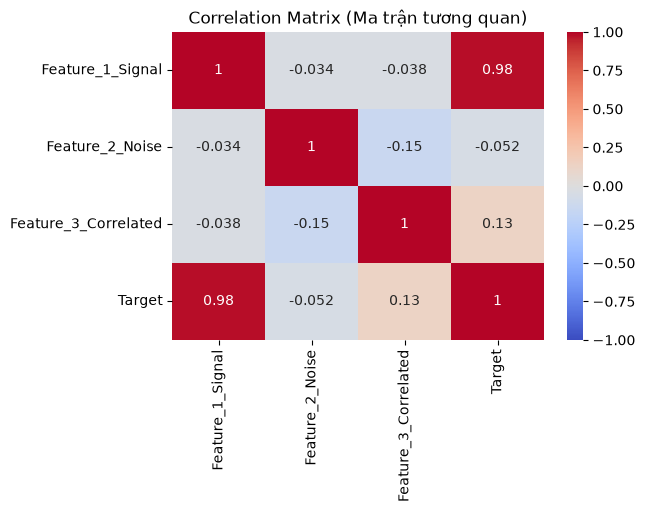

In [12]:
# Tạo tập dữ liệu giả lập cho Feature Selection
np.random.seed(42)
X = pd.DataFrame({
    'Feature_1_Signal': np.random.rand(100),
    'Feature_2_Noise': np.random.rand(100),
    'Feature_3_Correlated': np.random.rand(100)
})
y = 3 * X['Feature_1_Signal'] + 0.5 * X['Feature_3_Correlated'] + np.random.randn(100)*0.1

X['Target'] = y
corr_matrix = X.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix (Ma trận tương quan)")
plt.show()

# Xóa Target khỏi X cho các bước tiếp theo
X = X.drop('Target', axis=1)


### 3.2 Wrapper Methods
Wrapper methods sử dụng một mô hình dự đoán để chấm điểm các tập con của features. Chúng tính toán tốn kém nhưng có độ chính xác cao.

#### Recursive Feature Elimination (RFE)
RFE bắt đầu với tất cả các features, xây dựng một mô hình, loại bỏ feature ít quan trọng nhất dựa trên trọng số mô hình, và lặp lại.


In [13]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

model = LinearRegression()
rfe = RFE(estimator=model, n_features_to_select=2)
rfe.fit(X, y)

print("Xếp hạng Feature bằng RFE (1 nghĩa là được chọn):")
for feature, rank in zip(X.columns, rfe.ranking_):
    print(f"{feature}: {rank}")


Xếp hạng Feature bằng RFE (1 nghĩa là được chọn):
Feature_1_Signal: 1
Feature_2_Noise: 2
Feature_3_Correlated: 1


### 3.3 Embedded Methods
Embedded methods thực hiện Feature Selection tự động trong quá trình huấn luyện mô hình.
* **Lasso (L1 Regularization):** Thu hẹp hệ số của các tính năng vô dụng về chính xác 0.
* **Tree-based Feature Importance:** Random Forests và XGBoost tự nhiên đo lường mức độ đóng góp của từng feature trong việc giảm tạp chất (Gini/Entropy).


In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

importances = rf.feature_importances_
for feature, imp in zip(X.columns, importances):
    print(f"{feature}: {imp:.4f}")


Feature_1_Signal: 0.9736
Feature_2_Noise: 0.0062
Feature_3_Correlated: 0.0202


---
## Phần 4: Bài tập thực hành tổng hợp (Comprehensive Practice)
---
> **Hướng dẫn:** Các bài tập sau đại diện cho một luồng Data Preparation từ đầu đến cuối thực tế dành cho một Quantitative Risk Analyst. Bạn KHÔNG được cung cấp code giải mẫu. Bạn phải tự viết nó dựa trên lý thuyết ở trên.

### Case Study: Mô hình hóa Rủi ro Tín dụng
Bạn được cung cấp một tập dữ liệu `credit_risk_raw.csv` chứa các hồ sơ vay vốn trong quá khứ.

### Nhiệm vụ 1: Data Cleaning
1. Xác định tất cả các cột chứa Missing Values.
2. Đối với cột `Annual_Income`, hãy Impute Missing Values bằng cách sử dụng **Median** để tránh ảnh hưởng của các outliers siêu giàu.
3. Đối với cột `Employment_Length`, hãy Impute Missing Values bằng cách sử dụng **Mode**.
4. Tỷ lệ `Debt_To_Income` chứa các Outliers cực đoan (ví dụ: 999% do lỗi nhập liệu). Sử dụng phương pháp **IQR** để xác định những lỗi này và **Winsorize** chúng ở bách phân vị thứ 99.

### YOUR CODE HERE ###


In [15]:
# YOUR CODE HERE


### Nhiệm vụ 2: Data Transformation
1. Cột `Loan_Status` chứa "Approved" và "Rejected". Sử dụng **Label Encoding** để chuyển đổi thành 1 và 0.
2. Cột `Home_Ownership` có 4 danh mục (RENT, OWN, MORTGAGE, OTHER). Áp dụng **One-Hot Encoding** cho cột này.
3. Scale các cột `Annual_Income`, `Loan_Amount`, và `Credit_Score` bằng cách sử dụng **StandardScaler**.

### YOUR CODE HERE ###


In [16]:
# YOUR CODE HERE


### Nhiệm vụ 3: Feature Selection & Imbalance
1. Tập dữ liệu bị mất cân bằng (85% Approved, 15% Rejected). Tách các features (X) và target (y) của bạn, và áp dụng **SMOTE** để cân bằng tập huấn luyện.
2. Huấn luyện một `RandomForestClassifier` trên tập dữ liệu đã cân bằng và vẽ biểu đồ **Feature Importances**. 3 Features nào quan trọng nhất trong việc quyết định phê duyệt khoản vay?

### YOUR CODE HERE ###


In [17]:
# YOUR CODE HERE
